In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2, norm
from scipy.interpolate import interp1d
from scipy.special import factorial
from scipy.integrate import quad
import os
import sys
sys.path.append('/home/astridaurora/HESE-7-year-data-release/HESE-7-year-data-release')
from Astrid.effective_area import bin_edges_to_centers, bin_centers_to_edges, apply_energy_smearing
import nuSIprop

import ultranest


energy_bins = np.logspace(4, 7, 3*20+1)
energy_centers = bin_edges_to_centers(energy_bins)
energy_bins_low_resolution = np.logspace(4, 7, 20+1)
energy_centers_low_resolution = bin_edges_to_centers(energy_bins_low_resolution)

livetime12 = 12*365*24*3600


hese12_events_df = pd.read_csv('4_to_7_HESE12/20bins/hese12_20bins_df.csv', index_col=0)

background_df = pd.read_csv('4_to_7_HESE12/20bins/background_20bins_df.csv', index_col=0)
background_df.rename(columns={'background': 'events'}, inplace=True)


effective_area_df = pd.read_csv('4_to_7_HESE12/60bins/effective_area_4_to_7.csv', index_col=0)

In [6]:
def total_events(flx, eff, livetime, norm, delta_E, save_to_csv=False):
    # Interpolate `flx` to the same energy bins as `eff`
    flx_interpolated = pd.DataFrame(
    {col: interp1d(flx.index, flx[col], bounds_error=False, fill_value="extrapolate")(eff.index)
     for col in flx.columns},
    index=eff.index)
    
    if eff['nu_e'].any() < 0:
        print('Negative effective area found')
    if eff['nu_mu'].any() < 0:
        print('Negative effective area found')
    if eff['nu_tau'].any() < 0:
        print('Negative effective area found')
    

    total_events_df = flx_interpolated * eff * livetime * norm 
    negative_mask = total_events_df < 0
    total_events_df[negative_mask] = 0
        
    #total_events_df = flx * eff_interpolated * livetime
    total_events_df['total_events'] = delta_E * (total_events_df['nu_e'] + total_events_df['nu_mu'] + total_events_df['nu_tau'])
    #total_events_df.index = eff.index 

    if save_to_csv==True:
        total_events_df.to_csv('total_events.csv')

    return total_events_df


# --- Prior transform: maps [0,1]^3 -> (Mphi, g, si) ---
def prior_transform(cube):
    u_Mphi, u_g, u_si, u_norm = cube

    # Mphi log-uniform in [0.1, 1000]
    Mphi_min, Mphi_max = 0.01, 100
    Mphi = Mphi_min * (Mphi_max / Mphi_min) ** u_Mphi
    #Mphi = 10**(Mphi_min + (Mphi_max - Mphi_min) * u_Mphi)

    # g log-uniform in [1e-4, 1]
    g_min, g_max = 1e-5, 1.0
    g = g_min * (g_max / g_min) ** u_g
    #g = 10**(g_min + (g_max - g_min) * u_g)

    # si uniform in [2.0, 3.0]
    si = 2.0 + (3.5 - 2.0) * u_si

    # norm log-uniform in [1e-19, 5e-17]
    norm_min, norm_max = 1e-19, 5e-17
    norm = norm_min * (norm_max / norm_min) ** u_norm

    #return np.stack([Mphi, g, si, norm], axis=1)
    return Mphi, g, si, norm

#return np.column_stack([Mphi, g, si])


def log_likelihood_poisson(data, predicted):
    # From Poisson distribution 
    return np.sum(-predicted + data*np.log(predicted) - np.log(factorial(data)))

def log_likelihood_gaussian(data, predicted, sigma):
    return np.sum(-0.5 * np.log(2 * np.pi) - np.log(sigma) - 0.5 * (data - predicted)**2 / sigma**2)


def log_likelihood(theta):

    Mphi, g, si = theta

    evolver.set_parameters(mphi=Mphi*1e6, g=g, si=si)
    evolver.evolve()
    flux = evolver.get_flux_fla()

    flx_df = pd.DataFrame(flux.T, index=energies, columns=['nu_e', 'nu_mu', 'nu_tau'])
    flx_df.index = flx_df.index / 1e9

    nuSIprop_df = total_events(flx=effective_area_df, eff=flx_df, livetime=livetime12, norm=1e-4, delta_E=delta_E)
    nuSIprop_smeared = apply_energy_smearing(energies=nuSIprop_df.index.values, events=nuSIprop_df['total_events'].values, resolution=0.1)
    nuSIprop_binned_events, _ = np.histogram(nuSIprop_df.index.values, weights=nuSIprop_smeared, bins=energy_bins_low_resolution)

    predicted = nuSIprop_binned_events + background_df['events'].values

    return log_likelihood_poisson(data=hese12_events_df['events'].values.astype(int), predicted=predicted)

# --- Likelihood wrapper ---
def loglike(theta):
    return log_likelihood(theta)  # your existing function




In [4]:
# --- Run UltraNest ---
sampler = ultranest.ReactiveNestedSampler(
    ['Mphi', 'g', 'si'],  # parameter names
    loglike,
    prior_transform
)



In [6]:
sampler.print_results()


logZ = -38.814 +- 0.176
  single instance: logZ = -38.814 +- 0.099
  bootstrapped   : logZ = -38.792 +- 0.176
  tail           : logZ = +- 0.010
insert order U test : converged: True correlation: inf iterations

    Mphi                : 0     │▇▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁│1000      51 +- 145
    g                   : 0.000 │▇▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁ ▁▁▁▁▁▁▁▁  ▁▁▁▁│1.000     0.031 +- 0.097
    si                  : 2.267 │ ▁   ▁ ▁ ▁    ▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▂▂▂▃▃▄▅▅▆▇│3.000     2.916 +- 0.077



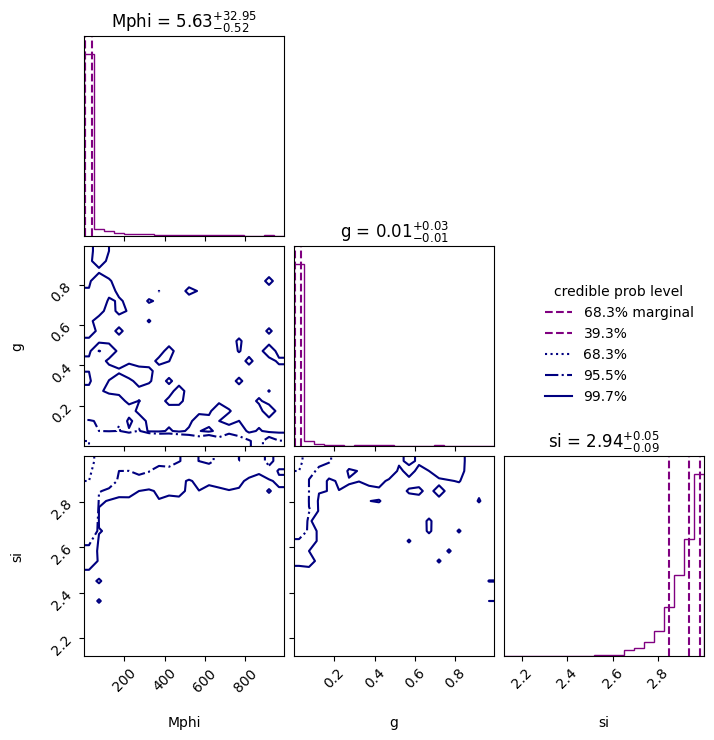

In [7]:
sampler.plot_corner()

[1.0000e+03 2.1500e+03 4.6400e+03 1.0000e+04 2.1500e+04 4.6400e+04
 1.0000e+05 2.1540e+05 4.6420e+05 1.0000e+06 2.1544e+06 4.6416e+06
 1.0000e+07 1.0000e+08]
sigma1:  [0.00000000e+00 5.59285714e-08 2.04878049e-08 9.14754098e-09
 6.88695652e-09 5.69739130e-09 4.11764706e-09 3.19687500e-09
 2.97230769e-09 2.38431373e-09 0.00000000e+00 1.92000000e-09
 0.00000000e+00]
sigma2:  [1.         0.03571429 0.02439024 0.01639344 0.04347826 0.09565217
 0.17647059 0.03125    0.29230769 0.25490196 1.         0.2
 1.        ]


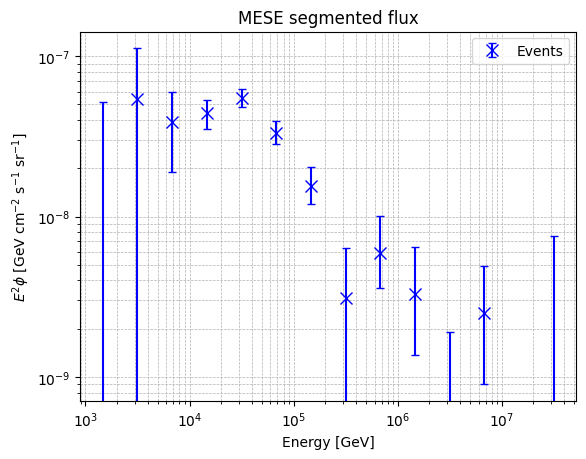

In [20]:
evolver = nuSIprop.pyprop(mphi = 50*1e6, # Mediator mass [eV]
			  g = 0.1, # Coupling
			  mntot = 0.1, # Sum of neutrino masses [eV]
			  si = 2.85, # Spectral index
			  norm = 1e-10, # Normalization of the free-streaming flux at 100 TeV [Default = 1]
			  majorana = True, # Majorana neutrinos? [Default = True]
			  non_resonant = True, # Include non s-channel contributions? Relevant for couplings g>~0.1 [Default = True]
			  normal_ordering = True, # Normal neutrino mass ordering? [Default = True]
			  N_bins_E = 300, # Number of energy bins, uniformly distributed in log space [Default = 300]
			  lEmin = 12, # log_10 (E_min/eV) [Default = 13]
			  lEmax = 17, # log_10 (E_max/eV) [Default = 17]
			  zmax = 5, # Largest redshift at which sources are included [Default = 5]
			  flav = 2, # Flavor of interacting neutrinos [0=e, 1=mu, 2=tau. Default = 2]
			  phiphi = True # Consider double-scalar production? If set to true, the files xsec/alpha_phiphi.bin and xsec/alphatilde_phiphi.bin must exist [Default = False]
                          )

energies = evolver.get_energies()
bin_edges_high_resolution = bin_centers_to_edges(energies)
delta_E_nuSIprop = np.diff(bin_edges_high_resolution)    # Delta E in eV   

energy_edges_MESE = [1.0, 2.15, 4.64, 10.0, 21.5, 46.4, 100.0, 215.4, 464.2, 1000.0, 2154.4, 4641.6, 10000.0, 100000.0]
energy_centers_MESE = [1.47, 3.16, 6.81, 14.7, 31.6, 68.1, 146.8, 316.2, 681.3, 1467.8, 3162.3, 6812.9, 31622.8]
energy_edges_MESE = np.asarray(energy_edges_MESE)
energy_centers_MESE = np.asarray(energy_centers_MESE)
energy_edges_MESE *= 1e3 # GeV
energy_centers_MESE *= 1e3 # GeV
print(energy_edges_MESE)
delta_E = energy_edges_MESE[1:] - energy_edges_MESE[0:-1]

norm_segmented = [0.0, 5.4, 3.9, 4.41, 5.51, 3.34, 1.55, 0.31, 0.59, 0.327, 0.0, 0.25, 0.0]
sigma_upper = [5.2, 5.8, 2.1, 0.93, 0.72, 0.63, 0.50, 0.33, 0.42, 0.32, 0.19, 0.24, 0.76]
sigma_lower = [0.0, 5.4, 2.0, 0.90, 0.66, 0.52, 0.35, 0.31, 0.23, 0.19, 0.0, 0.16, 0.0]
# physical pivot used by the paper (100 TeV). Convert to GeV.
# observed y (E^2 phi) and asymmetric errors in the same units
E0 = 1e5    # if E in GeV; 100 TeV = 1e5 GeV
y_obs = np.asarray(norm_segmented) * 1e-18 * E0**2
sigma_upper = np.asarray(sigma_upper) * 1e-18 * E0**2
sigma_lower = np.asarray(sigma_lower) * 1e-18 * E0**2

sigma1 = 2 * sigma_upper * sigma_lower / (sigma_upper + sigma_lower)    # Acts as an 'average width'
sigma2 = (sigma_upper - sigma_lower) / (sigma_upper + sigma_lower)       # Encodes the asymmetry
print('sigma1: ', sigma1)
print('sigma2: ', sigma2)


# Factor of 1e-10 to account for the norm at 100 TeV, as phi = norm * (E/100TeV)**2
plt.errorbar(energy_centers_MESE, y_obs, 
             yerr=[sigma_lower, sigma_upper], 
             fmt='x', color='blue', label='Events', capsize=3, markersize=8, linestyle='none')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Energy [GeV]')
plt.ylabel('$E^2 \phi$ [GeV cm$^{-2}$ s$^{-1}$ sr$^{-1}$]')
plt.title('MESE segmented flux')
plt.legend()
plt.grid(axis='both', which='both', linestyle='--', linewidth=0.5)
plt.show()


"""
# helper: compute model bin-averaged E^2 phi
def bin_avg_E2phi(phi_func, Emin, Emax):
    # Integrate E^2 * phi(E) over the bin and divide by bin width
    num, _ = quad(lambda E: (E**2) * phi_func(E), Emin, Emax, epsabs=0, epsrel=1e-4)
    return num / (Emax - Emin)

def model_predict_E2phi_per_bin_old(spl=True):
    # phi_func should accept E (same units as E0)
    # phi_func must return differential flux phi(E;theta) in same units that make E^2 phi comparable to y_obs
    if spl:
        phi_func = lambda E: SPL_flux(energies=E)   # user-supplied function
    else:
        phi_func = lambda E: BPL_flux(energies=E) 
    preds = []
    for Emin, Emax in zip(energy_edges_MESE[:-1], energy_edges_MESE[1:]):
        preds.append(bin_avg_E2phi(phi_func, Emin, Emax))
    return np.array(preds)  # shape (nbins,)

def model_predict_E2phi_per_bin(theta, model_flux, bin_edges):
    #norm, si1, si2, E_break = theta
    y_bin_avg = []
    for i in range(len(bin_edges)-1):
        Emin, Emax = bin_edges[i], bin_edges[i+1]
        Es = np.logspace(np.log10(Emin), np.log10(Emax), 200)
        vals = model_flux(theta,energies=Es) * Es**2
        integral = np.trapz(vals, Es)
        avg = integral / (Emax - Emin)   # <-- critical
        y_bin_avg.append(avg)
    return np.array(y_bin_avg)"""

def loglike_nuSIprop(theta):
    #Mphi, g, mntot, si, norm = theta
    Mphi, g, si, norm = theta
    print('theta: ', theta)
    try:
        y_pred = nuSIprop_flux_binavg_trap(theta)

        # sanity checks
        if not np.all(np.isfinite(y_pred)):
            print('Warning: Non-finite predictions y_pred for parameters: Mphi={Mphi}, g={g}, mntot={mntot}, si={si}, norm={norm}')
            print(y_pred)
            return -np.inf

        y_err = sigma1 + sigma2 * (y_pred - y_obs)
        print('y_err: ', y_err)

        # make sure errors are positive
        if np.any(y_err <= 0):
            print('Warning: y_err <= 0 for parameters: Mphi={Mphi}, g={g}, mntot={mntot}, si={si}, norm={norm}')
            print('y_err: ', y_err)
            #return -np.inf
            y_err[y_err <= 0] = 1e-1

        ll = -0.5 * np.sum((y_obs - y_pred)**2 / y_err**2)
        print(-0.5 * (y_obs - y_pred)**2 / y_err**2)

        if not np.isfinite(ll):
            print('Warning: Non-finite ll for parameters: Mphi={Mphi}, g={g}, mntot={mntot}, si={si}, norm={norm}')
            print('ll: ', ll)
            #return -np.inf

        return ll
    except Exception as e:
        print("Error in likelihood:", e, theta)
        return -np.inf


def nuSIprop_flux_binavg_trap(theta):
    #Mphi, g, mntot, si, norm = theta
    Mphi, g, si, norm = theta
    evolver.set_parameters(mphi=Mphi*1e6, g=g, mntot=mntot, si=si, norm=norm)
    evolver.evolve()
    flux = evolver.get_flux_fla()                      # shape (nE, flavors)
    E_samples = evolver.get_energies() / 1e9           # ensure same units as energy_edges_MESE (GeV)
    perflavor = (flux[0,:] + flux[1,:] + flux[2,:]) / 3.0  # or flux.T/columns depending on shape
    print('perflavor: ', perflavor)

    preds = []
    for Emin, Emax in zip(energy_edges_MESE[:-1], energy_edges_MESE[1:]):
        # select indices inside the bin (include endpoints carefully)
        mask = (E_samples >= Emin) & (E_samples <= Emax)
        Es = E_samples[mask]
        phis = perflavor[mask]

        if Es.size == 0:
            # fallback: interpolate phi on a fine grid and integrate, or use nearest neighbor
            preds.append(0.0)
            continue

        # integrate E^2 * phi(E) over the bin using trapezoid rule
        integrand = (Es**2) * phis
        integral = np.trapz(integrand, Es)   # approximates ∫ E^2 phi dE
        preds.append(integral / (Emax - Emin))   # bin-averaged E^2 phi

    return np.array(preds)



def SPL_flux(norm=2.13, si=2.548, energies=energy_centers_MESE):
    # SPL model flux
    # Normalized at E = 100TeV
    # Best fit MESE: norm = 2.13^{0.18}_{-0.17}, si = 2.548^{0.039}_{-0.041}
    
    return  norm * (energies / E0)**(-si)
    
    
def BPL_flux(norm=2.28, si1=1.72, si2=2.839, E_break=10**4.524, energies=energy_centers_MESE):
    # BPL model flux
    # Normalized at E = 100TeV = 1e5 GeV
    # Best fit MESE: norm = 2.28, si1 = 1.72, si2 = 2.839, E_break = 10**(4.524) GeV
    if E_break > 1e5:
        norm_break  = norm * (E_break / E0)**(-si1)
    else:
        norm_break  = norm * (E_break / E0)**(-si2)
    
    # If used for integration within the bin, energies will be a single value.
    if isinstance(energies, float):
        if energies < E_break:
            flux = norm_break * (energies / E0)**(-si1)
        else:
            flux = norm_break * (energies / E0)**(-si2)
    else:
        flux = np.zeros(len(energies))
        for i, E in enumerate(energies):
            if E < E_break:
                flux[i] = norm_break * (E / E_break)**(-si1)
            else:
                flux[i] = norm_break * (E / E_break)**(-si2)
    return flux 


def LP_flux(norm=2.58, alpha=2.669, beta=0.359, energies=energy_centers_MESE):
    # Log Parabola model flux
    # Normalized at E = 100TeV
    # Best fit MESE: norm = 2.42, alpha = 2.05, beta = 2.54
    return  norm * (energies / E0)**(-alpha - beta * np.log10(energies / E0)) 


def loglike_LP(theta):
    # log likelihood for LP model
    # theta = (norm, alpha, beta)
    norm, alpha, beta = theta
    y_pred = integrate_model_E2phi(theta, energy_edges_MESE)
    y_err = sigma1 + sigma2 * (y_pred - y_obs)
    ll = -0.5 * np.sum((y_obs - y_pred)**2 / y_err**2) #- np.sum(np.log(y_err))
    return ll


def loglike_BPL(theta):
    # log likelihood for BPL model
    # theta = (norm, si1, si2, E_break)
    norm, si1, si2, E_break = theta
    y_pred = model_predict_E2phi_per_bin(theta, BPL_flux, energy_edges_MESE)
    y_err = sigma1 + sigma2 * (y_pred - y_obs)
    ll = -0.5 * np.sum((y_obs - y_pred)**2 / y_err**2)
    return ll


In [69]:
def integrate_nuSIprop_E2phi(theta, interaction=True):
    #Mphi, g, si = theta
    #Mphi, g, mntot, si, norm = theta
    if interaction:
        if len(theta) == 4:
            Mphi, g, si, norm = theta
        elif len(theta) == 5:
            Mphi, g, mntot, si, norm = theta
        evolver.set_parameters(mphi=Mphi*1e6, g=g, mntot=mntot, si=si, norm=norm*1e-18)
    else:
        si, norm = theta
        evolver.set_parameters(si=si, norm=norm*1e-18)
    #evolver.set_parameters(mphi=Mphi*1e6, g=g, mntot=mntot, si=si, norm=norm)
    
    evolver.evolve()
    flux = evolver.get_flux_fla()                      # shape (nE, flavors)
    E_samples = evolver.get_energies() / 1e9           # ensure same units as energy_edges_MESE (GeV)
    perflavor = (flux[0,:] + flux[1,:] + flux[2,:]) / 3.0  # or flux.T/columns depending on shape

    preds = []
    for Emin, Emax in zip(energy_edges_MESE[:-1], energy_edges_MESE[1:]):
        # select indices inside the bin (include endpoints carefully)
        mask = (E_samples >= Emin) & (E_samples <= Emax)
        Es = E_samples[mask]
        phis = perflavor[mask]

        if Es.size == 0:
            # fallback: interpolate phi on a fine grid and integrate, or use nearest neighbor
            preds.append(0.0)
            continue

        # integrate E^2 * phi(E) over the bin using trapezoid rule
        integrand = (Es**2) * phis
        integral = np.trapz(integrand, Es)   # approximates ∫ E^2 phi dE
        preds.append(integral / (Emax - Emin))   # bin-averaged E^2 phi

    return np.array(preds)


def integrate_model_E2phi(theta, bin_edges):
    #norm, si1, si2, E_break = theta

    y_bin_avg = []
    for i in range(len(bin_edges)-1):
        Emin, Emax = bin_edges[i], bin_edges[i+1]
        Es = np.logspace(np.log10(Emin), np.log10(Emax), 200)
        if len(theta) == 2:
            norm, si = theta
            vals = SPL_flux(norm, si, energies=Es) * Es**2
        elif len(theta) == 4:
            norm, si1, si2, E_break = theta
            vals = BPL_flux(norm, si1, si2, E_break, energies=Es) * Es**2
        elif len(theta) == 3:
            norm, alpha, beta = theta
            vals = LP_flux(norm, alpha, beta, energies=Es) * Es**2

        integral = np.trapz(vals, Es)
        avg = integral / (Emax - Emin)   # <-- critical
        y_bin_avg.append(avg)
    return np.array(y_bin_avg)


def loglike_nuSIprop(theta):
    #Mphi, g, mntot, si, norm = theta
    Mphi, g, mntot, si, norm = theta
    y_pred = integrate_nuSIprop_E2phi(theta, interaction=True)
    y_err = sigma1 + sigma2 * (y_pred - y_obs)
    if np.any(y_err <= 0):
        print('Zeros in y_err for parameters: Mphi=', Mphi,', g=', g, ' mntot=', mntot, ' si=', si,', norm=', norm)
        print('y_err: ', y_err)
        print('y_pred: ', y_pred)
        y_err[y_err <= 0] = 1e-11
    ll = -0.5 * np.sum((y_obs - y_pred)**2 / y_err**2) #- np.sum(np.log(y_err))
    print('log likelihood nuSIprop: ', -0.5 * (y_obs - y_pred)**2 / y_err**2)
    return ll

def loglike(theta, interaction=True):
    # Valid for all flux models
    if interaction:
        y_pred = integrate_nuSIprop_E2phi(theta, interaction=True)
    else:
        y_pred = integrate_model_E2phi(theta, energy_edges_MESE)
    y_err = sigma1 + sigma2 * (y_pred - y_obs)
    print('y_err: ', y_err)
    if np.any(y_err <= 0):
        print('Zeros or negatives in y_err')
        y_err[y_err <= 0] = np.abs(y_err[y_err <= 0])
        obs = y_obs[y_err <= 0]
        pred = y_pred[y_err <= 0]
        y_obs[y_err <= 0] = pred
        y_pred[y_err <= 0] = obs
        

    ll = -0.5 * np.sum((y_obs - y_pred)**2 / y_err**2) #- np.sum(np.log(y_err))
    return ll

In [51]:

#norm_segmented = [0.0, 5.4, 3.9, 4.41, 5.51, 3.34, 1.55, 0.31, 0.59, 0.327, 0.0, 0.25, 0.0]
#sigma_upper = [5.2, 5.8, 2.0, 0.93, 0.72, 0.56, 0.50, 0.38, 0.42, 0.45, 0.218, 0.19, 0.76]
#sigma_lower = [0.0, 5.4, 2.0, 0.90, 0.66, 0.52, 0.35, 0.31, 0.183, 0.187, 0.0, 0.157, 0.0]
#sigma_upper = [5.2, 5.8, 2.1, 0.93, 0.72, 0.63, 0.50, 0.33, 0.42, 0.32, 0.19, 0.24, 0.76]
#sigma_lower = [0.0, 5.4, 2.0, 0.90, 0.66, 0.52, 0.35, 0.31, 0.23, 0.08, 0.0, 0.16, 0.0]


# Energies within sensitivity range of SPL

energy_edges_MESE = [1.0, 2.15, 4.64, 10.0, 21.5, 46.4, 100.0, 215.4, 464.2, 1000.0, 2154.4, 4641.6, 10000.0, 100000.0]
energy_centers_MESE = [1.47, 3.16, 6.81, 14.7, 31.6, 68.1, 146.8, 316.2, 681.3, 1467.8, 3162.3, 6812.9, 31622.8]

#energy_edges_MESE = [4.64, 10.0, 21.5, 46.4, 100.0, 215.4, 464.2, 1000.0, 2154.4, 4641.6, 10000.0]
#energy_centers_MESE = [6.81, 14.7, 31.6, 68.1, 146.8, 316.2, 681.3, 1467.8, 3162.3, 6812.9]
energy_edges_MESE = np.asarray(energy_edges_MESE)
energy_centers_MESE = np.asarray(energy_centers_MESE)
energy_edges_MESE *= 1e3 # GeV
energy_centers_MESE *= 1e3 # GeV


norm_segmented = [0.0, 5.4, 3.9, 4.41, 5.51, 3.34, 1.55, 0.31, 0.59, 0.327, 0.0, 0.25, 0.0]
#sigma_upper = [2.0, 0.93, 0.72, 0.56, 0.50, 0.38, 0.42, 0.45, 0.218]
#sigma_lower = [2.0, 0.90, 0.66, 0.52, 0.35, 0.31, 0.183, 0.187, 0.0]
sigma_upper = [5.2, 5.8, 2.1, 0.93, 0.72, 0.63, 0.50, 0.33, 0.42, 0.32, 0.19, 0.24, 0.76]
sigma_lower = [0.0, 5.4, 2.0, 0.90, 0.66, 0.52, 0.35, 0.31, 0.23, 0.187, 0.0, 0.16, 0.0]

# physical pivot used by the paper (100 TeV). Convert to GeV.
# observed y (E^2 phi) and asymmetric errors in the same units
E0 = 1e5    # if E in GeV; 100 TeV = 1e5 GeV
y_obs = np.asarray(norm_segmented) * 1e-18 * E0**2
sigma_upper = np.asarray(sigma_upper) * 1e-18 * E0**2
sigma_lower = np.asarray(sigma_lower) * 1e-18 * E0**2

sigma1 = 2 * sigma_upper * sigma_lower / (sigma_upper + sigma_lower)    # Acts as an 'average width'
sigma2 = (sigma_upper - sigma_lower) / (sigma_upper + sigma_lower)       # Encodes the asymmetry
print('sigma1: ', sigma1)
print('sigma2: ', sigma2)


loglike_spl = loglike(theta=[2.13*1e-18, 2.548], interaction=False)
loglike_bpl = loglike(theta=[2.28*1e-18, 1.72, 2.839, 10**4.524], interaction=False)

#theta = [2.698887410360228 * 1e-18, 2.6994688572999883, 0.4217432311439763]
#loglike_lp = loglike(theta, interaction=False)
loglike_lp = loglike(theta=[2.58*1e-18, 2.668, 0.359], interaction=False)

print('loglike_spl: ', loglike_spl)
print('loglike_bpl: ', loglike_bpl)
print('loglike_lp: ', loglike_lp)

TS_BPL = 2 * (loglike_bpl - loglike_spl)
TS_LP = 2 * (loglike_lp - loglike_spl)
print('TS_BPL: ', TS_BPL)
print('TS_LP: ', TS_LP)





sigma1:  [0.00000000e+00 5.59285714e-08 2.04878049e-08 9.14754098e-09
 6.88695652e-09 5.69739130e-09 4.11764706e-09 3.19687500e-09
 2.97230769e-09 2.36055227e-09 0.00000000e+00 1.92000000e-09
 0.00000000e+00]
sigma2:  [1.         0.03571429 0.02439024 0.01639344 0.04347826 0.09565217
 0.17647059 0.03125    0.29230769 0.26232742 1.         0.2
 1.        ]
y_err:  [2.11302351e-07 5.89549337e-08 2.17574918e-08 9.40537670e-09
 6.19922639e-09 4.96869888e-09 4.36990124e-09 3.44737988e-09
 3.38128978e-09 2.76010304e-09 3.14737682e-09 1.83334302e-09
 7.68748146e-10]
y_err:  [2.41993361e-08 5.50715767e-08 2.04440552e-08 9.18050630e-09
 6.74058984e-09 5.44151049e-09 4.22999148e-09 3.36482962e-09
 2.54865100e-09 2.11596317e-09 1.22773799e-09 1.54896345e-09
 1.48217522e-10]
y_err:  [2.77834895e-08 5.54636982e-08 2.07668458e-08 9.27362175e-09
 6.42057834e-09 5.53610779e-09 4.72110499e-09 3.39432082e-09
 2.39135235e-09 1.85860419e-09 3.92481691e-10 1.43895142e-09
 3.60385508e-12]
loglike_spl:  -14.

LP_bin_avg:  [2.77834895e-08 4.09835487e-08 5.04406773e-08 5.17909267e-08
 4.43733017e-08 3.17138542e-08 1.89195949e-08 9.41826612e-09
 3.91252119e-09 1.35655882e-09 3.92481691e-10 9.47570892e-11
 3.60385508e-12]
lp_flux raw:  [2.69196359e-08 4.03405382e-08 5.03828282e-08 5.23522480e-08
 4.52862503e-08 3.25898916e-08 1.95104538e-08 9.72543128e-09
 4.03311942e-09 1.39202539e-09 3.99819850e-10 9.55689397e-11
 3.14679836e-12]
BPL_bin_avg:  [2.41993361e-08 3.00041463e-08 3.72062652e-08 4.61108843e-08
 5.17335662e-08 3.07248824e-08 1.61366184e-08 8.47454794e-09
 4.45064816e-09 2.33761899e-09 1.22773799e-09 6.44817262e-10
 1.48217522e-10]
bpl_flux raw:  [2.38466677e-08 2.95454923e-08 3.66319501e-08 4.54388886e-08
 5.62977749e-08 3.14720056e-08 1.65215841e-08 8.67894311e-09
 4.55789104e-09 2.39387424e-09 1.25728077e-09 6.60342557e-10
 1.82152266e-10]


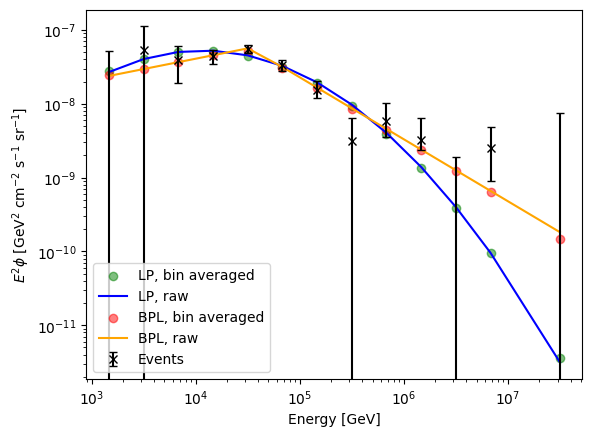

In [46]:
lp_flux = LP_flux(energies=energy_centers_MESE, alpha=2.668, beta=0.359, norm=2.58*1e-18)
LP_bin_avg = integrate_model_E2phi(theta=[2.58*1e-18, 2.668, 0.359], bin_edges=energy_edges_MESE)
print('LP_bin_avg: ', LP_bin_avg)
print('lp_flux raw: ', lp_flux * energy_centers_MESE**2)

bpl_flux = BPL_flux(energies=energy_centers_MESE, si1=1.72, si2=2.839, E_break=10**4.524, norm=2.28*1e-18)
BPL_bin_avg = integrate_model_E2phi(theta=[2.28*1e-18, 1.72, 2.839, 10**4.524], bin_edges=energy_edges_MESE)
print('BPL_bin_avg: ', BPL_bin_avg)
print('bpl_flux raw: ', bpl_flux * energy_centers_MESE**2)

plt.scatter(energy_centers_MESE, LP_bin_avg, label='LP, bin averaged', alpha=0.5, color='green')
plt.plot(energy_centers_MESE, lp_flux * energy_centers_MESE**2, label='LP, raw', color='blue')
plt.scatter(energy_centers_MESE, BPL_bin_avg, label='BPL, bin averaged', alpha=0.5, color='red')
plt.plot(energy_centers_MESE, bpl_flux * energy_centers_MESE**2, label='BPL, raw', color='orange')
plt.errorbar(energy_centers_MESE, y_obs, 
             yerr=[sigma_lower, sigma_upper], 
             fmt='x', color='black', label='Events', capsize=3, markersize=6, linestyle='none')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Energy [GeV]')
plt.ylabel('$E^2 \phi$ [GeV$^2$ cm$^{-2}$ s$^{-1}$ sr$^{-1}$]')
plt.legend()
plt.show()


In [75]:

#theta = [20, 0.01, 0.07, 2.548, 2*2.13*1e-18]
#theta = [39.03059910524562, 0.00042970221381601336, 0.114384446591275, 2.6855511867911517, 1.3544599291118502e-18]
#theta = [7.915010269044294, 0.0011067838169519161, 0.0626165943321897, 3.0311637298813476, 2.550226573682637e-09]
#theta = [12.51097031040926, 0.014107459327646643, 0.1385678945551038, 3.5915912797202445, 6.519071442950406e-10]
#theta = [34.62904650575734, 0.24812191654151713, 0.09347253611024776, 2.3095098825940363, 6.952525597298649e-18]
"""
nuSIprop_flx_bin_averaged = nuSIprop_flux_binavg_trap(theta)
print('nuSIprop_flx_bin_averaged: ', nuSIprop_flx_bin_averaged)

y_err = sigma1 + sigma2 * (nuSIprop_flx_bin_averaged - y_obs)
print('y_err: ', y_err)
print('log likelihood: ', -0.5 * (y_obs - nuSIprop_flx_bin_averaged)**2 / y_err**2 - np.log(y_err))
print('total log likelihood: ', -0.5 * np.sum((y_obs - nuSIprop_flx_bin_averaged)**2 / y_err**2))

"""
#print(perflavor)

spl_flux = SPL_flux(energies=energy_centers_MESE, si=2.548, norm=2.13*1e-18)
#lp_flux = LP_flux(energies=energy_centers_MESE, alpha=3.164431771688147, beta=0.999686262464528, norm=2.4854813536011315*1e-18)
bpl_flux = BPL_flux(energies=energy_centers_MESE, si1=1.72, si2=2.839, E_break=10**4.524, norm=2.28*1e-18)
lp_flux = LP_flux(energies=energy_centers_MESE, alpha=2.668, beta=0.359, norm=2.58*1e-18)


#print('total log likelihood_spl: ', -0.5 * np.sum((y_obs - spl_flux)**2 / y_err_spl**2) - np.sum(np.log(y_err_spl)))
#print('total log likelihood_lp: ', -0.5 * np.sum((y_obs - lp_flux)**2 / y_err_lp**2) - np.sum(np.log(y_err_lp)))
#theta_LP = [2.4854813536011315*1e-18, 3.164431771688147, 0.999686262464528]
#theta_LP = [2.4854813536011315*1e-18, 3.164431771688147, 0.999686262464528]
#log_like_LP = loglike_LP(theta_LP)

BPL_bin_avg = integrate_model_E2phi(theta=[2.28*1e-18, 1.72, 2.839, 10**4.524], bin_edges=energy_edges_MESE)
LP_bin_avg = integrate_model_E2phi(theta=[2.58*1e-18, 2.668, 0.359], bin_edges=energy_edges_MESE)

y_err_bpl = sigma1 + sigma2 * (BPL_bin_avg - y_obs)
y_err_lp = sigma1 + sigma2 * (LP_bin_avg - y_obs)

print('log likelihood_bpl: ', -0.5 * (y_obs - BPL_bin_avg)**2 / y_err_bpl**2)
print('total log likelihood_bpl: ', -0.5 * np.sum((y_obs - BPL_bin_avg)**2 / y_err_bpl**2))
print('log likelihood_lp: ', -0.5 * (y_obs - LP_bin_avg)**2 / y_err_lp**2)
print('total log likelihood_lp: ', -0.5 * np.sum((y_obs - LP_bin_avg)**2 / y_err_lp**2))

theta = [1, 0.05, 0.01, 2.4, 7]
nuSIprop_flx = integrate_nuSIprop_E2phi(theta, interaction=True)
print('nuSIprop_flx: ', nuSIprop_flx)
log_like_nuSIprop = loglike_nuSIprop(theta)

print('log likelihood_nuSIprop: ', log_like_nuSIprop)
evolver.set_parameters(mphi=theta[0]*1e6, g=theta[1], mntot=theta[2], si=theta[3], norm=theta[4]*1e-18)
evolver.evolve()
flux = evolver.get_flux_fla()
E = evolver.get_energies() / 1e9
perflavor = (flux[0,:] + flux[1,:] + flux[2,:]) / 3.0


#plt.plot(energy_centers_MESE, spl_flux * energy_centers_MESE**2, label='SPL, raw', alpha=0.5, color='blue')
#plt.plot(energy_centers_MESE, lp_flux * energy_centers_MESE**2, label='LP, raw')
plt.scatter(energy_centers_MESE, BPL_bin_avg, label='BPL, bin averaged', alpha=0.5, color='blue')
plt.scatter(energy_centers_MESE, LP_bin_avg, label='LP, bin averaged', alpha=0.5, color='green')

plt.plot(E, perflavor * E**2, label='nuSIprop, raw', linestyle='--', color='red')
plt.scatter(energy_centers_MESE, nuSIprop_flx, label='nuSIprop, bin averaged', color='red')
plt.errorbar(energy_centers_MESE, y_obs, 
             yerr=[sigma_lower, sigma_upper], 
             fmt='x', color='black', label='Events', capsize=3, markersize=5, linestyle='none')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Energy [GeV]')
plt.ylabel('$E^2 \phi$ [GeV$^2$ cm$^{-2}$ s$^{-1}$ sr$^{-1}$]')
plt.legend()
plt.show()




: 

In [44]:

from scipy.stats import norm

def loglike_asym_censored(y_obs, y_pred, is_upper):
    """
    Compute log-likelihood for data with asymmetric errors and upper limits.
    
    Parameters
    ----------
    y_obs : array-like
        Observed central values (for upper limits, can be 0.0 or np.nan).
    y_pred : array-like
        Predicted values from the model (same length as y_obs).
    sigma_minus : array-like
        Lower-side errors for each bin (0 if no lower error reported).
    sigma_plus : array-like
        Upper-side errors for each bin.
    is_upper : boolean array
        True if bin is an upper limit (only upper boundary reported).
    """
    y_obs   = np.asarray(y_obs)
    y_pred  = np.asarray(y_pred)
    #sigma_m = np.asarray(sigma_minus)
    #sigma_p = np.asarray(sigma_plus)
    is_upper = np.asarray(is_upper)

    logL = np.zeros_like(y_pred, dtype=float)

    # --- Upper limits: log CDF ---
    if np.any(is_upper):
        idx = np.nonzero(is_upper)[0]
        L = sigma_upper[idx]  # treat reported "+σ" as the limit value
        # choose σ from sigma_plus (uncertainty in upward fluctuations)
        sigma_tail = sigma_upper[idx]
        z = (L - y_pred[idx]) / sigma_tail
        logL[idx] = norm.logcdf(z)

    # --- Measured bins: split-normal ---
    if np.any(~is_upper):
        idx = np.nonzero(~is_upper)[0]
        y_o = y_obs[idx]
        y_p = y_pred[idx]
        res = y_p - y_o

        # pick σ depending on side
        sigma = np.where(res < 0, sigma_lower[idx], sigma_upper[idx])

        # normalization term (independent of y_pred)
        norm_term = np.log(sigma_lower[idx] + sigma_upper[idx])
        print('norm_term: ', norm_term)

        chi2_term = -0.5 * (res / sigma)**2
        print('chi2_term: ', chi2_term)
        logL[idx] = chi2_term - norm_term
    print('logL: ', logL)

    return np.sum(logL)


def split_normal_loglike(y_obs, y_pred, sigma_lower, sigma_upper, is_upper):
    y_obs   = np.asarray(y_obs)
    y_pred  = np.asarray(y_pred)
    is_upper = np.asarray(is_upper)

    logL = np.zeros_like(y_pred, dtype=float)
    norm = np.sqrt(2 /np.pi) / (sigma_lower + sigma_upper)
    
    for i in range(len(y_pred)):
        if y_pred[i] > y_obs[i]:
            logL[i] = -(y_pred[i] - y_obs[i])**2 / (2 * sigma_upper[i]**2) + np.log(norm[i])
        else:
            logL[i] = -(y_pred[i] - y_obs[i])**2 / (2 * sigma_lower[i]**2) + np.log(norm[i])
            
    return np.sum(logL)
    



# Mark upper-limit bins
is_upper = np.zeros_like(norm_segmented, dtype=bool)
print(is_upper)
is_upper[[0, 10, 12]] = True
print(is_upper)
# Example: evaluate log-likelihood for some model prediction
#y_pred_example = np.linspace(0, 6, len(norm_segmented))
y_pred_example = LP_bin_avg
print('y_pred_example: ', y_pred_example)
print('y_obs: ', y_obs)
logL_val = loglike_asym_censored(norm_segmented, y_pred_example, is_upper)

logL_split = split_normal_loglike(y_obs, y_pred_example, sigma_lower, sigma_upper, is_upper)

print("Total log-likelihood:", logL_val)
print("Total log-likelihood:", logL_split)


[False False False False False False False False False False False False
 False]
[ True False False False False False False False False False  True False
  True]
y_pred_example:  [3.29450280e-07 2.88078656e-07 2.16404289e-07 1.39835133e-07
 7.75954250e-08 3.69728123e-08 1.51506364e-08 5.33494783e-09
 1.61429488e-09 4.19855959e-10 9.38304996e-11 1.80192022e-11
 5.28577394e-13]
y_obs:  [0.00e+00 5.40e-08 3.90e-08 4.41e-08 5.51e-08 3.34e-08 1.55e-08 3.10e-09
 5.90e-09 3.27e-09 0.00e+00 2.50e-09 0.00e+00]
norm_term:  [-16.00476697 -17.00969377 -17.81636478 -18.09859724 -18.2809188
 -18.58319967 -18.86696785 -18.85146366 -19.0940253  -19.33697148]
chi2_term:  [-4.99999947e+15 -1.90124979e+16 -1.20049992e+17 -3.48485987e+17
 -2.06279581e+17 -9.80612226e+16 -4.99999983e+15 -3.29017011e+16
 -1.48101108e+16 -1.22070312e+16]
logL:  [-1.68600296e+01 -4.99999947e+15 -1.90124979e+16 -1.20049992e+17
 -3.48485987e+17 -2.06279581e+17 -9.80612226e+16 -4.99999983e+15
 -3.29017011e+16 -1.48101108e+16 -1.

energy centers withing sensitivity range:  [1.47000e+03 3.16000e+03 6.81000e+03 1.47000e+04 3.16000e+04 6.81000e+04
 1.46800e+05 3.16200e+05 6.81300e+05 1.46780e+06 3.16230e+06 6.81290e+06
 3.16228e+07]
energy edges:  [1.0000e+03 2.1500e+03 4.6400e+03 1.0000e+04 2.1500e+04 4.6400e+04
 1.0000e+05 2.1540e+05 4.6420e+05 1.0000e+06 2.1544e+06 4.6416e+06
 1.0000e+07 1.0000e+08]
sigma1:  [0.00000000e+00 5.59285714e+10 2.04878049e+10 9.14754098e+09
 6.88695652e+09 5.69739130e+09 4.11764706e+09 3.19687500e+09
 2.97230769e+09 9.96306069e+08 0.00000000e+00 1.92000000e+09
 0.00000000e+00]
sigma2:  [1.         0.03571429 0.02439024 0.01639344 0.04347826 0.09565217
 0.17647059 0.03125    0.29230769 0.68865435 1.         0.2
 1.        ]
SPL error:  [2.11302351e+11 5.89549337e+10 2.17574918e+10 9.40537670e+09
 6.19922639e+09 4.96869888e+09 4.36990124e+09 3.44737988e+09
 3.38128978e+09 2.04519522e+09 3.14737682e+09 1.83334302e+09
 7.68748146e+08]
BPL error:  [2.41993361e+10 5.50715767e+10 2.04440552e

/tmp/ipykernel_177170/3715863758.py:31: RuntimeWarning: invalid value encountered in log
  ll_LP = -0.5 * (y_obs - y_pred_LP_bin_avg)**2 / y_err_LP**2 - np.log(y_err_LP)


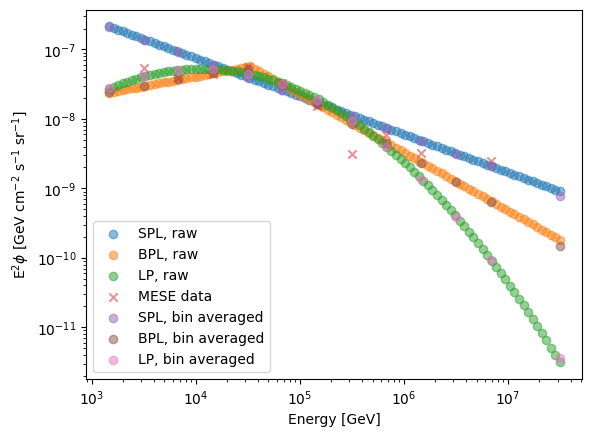

In [ ]:
# Old log-likelihood 
# beta=0.999686262464528
259.90095829579474
# beta=0.3
171.73448884583647

# New log-likelihood 
# beta=0.999686262464528
228.3864017476985
# beta=0.3
108.33382908865292



energy_centers_high_resolution = np.logspace(np.log10(energy_centers_MESE[0]), np.log10(energy_centers_MESE[-1]), 100)

y_pred_SPL_raw = SPL_flux(energies=energy_centers_high_resolution) * energy_centers_high_resolution**2
y_pred_BPL_raw = BPL_flux(energies=energy_centers_high_resolution) * energy_centers_high_resolution**2
y_pred_LP_raw = LP_flux(energies=energy_centers_high_resolution) * energy_centers_high_resolution**2

lower_index = 2
upper_index = -1

print('energy centers withing sensitivity range: ', energy_centers_MESE)
print('energy edges: ', energy_edges_MESE)
print('sigma1: ', sigma1)
print('sigma2: ', sigma2)

y_pred_SPL_bin_avg = model_predict_E2phi_per_bin(SPL_flux, energy_edges_MESE)
y_pred_BPL_bin_avg = model_predict_E2phi_per_bin(BPL_flux, energy_edges_MESE)
y_pred_LP_bin_avg = model_predict_E2phi_per_bin(LP_flux, energy_edges_MESE)

y_err_SPL = sigma1 + sigma2 * (y_pred_SPL_bin_avg - y_obs)
y_err_BPL = sigma1 + sigma2 * (y_pred_BPL_bin_avg - y_obs)
y_err_LP = sigma1 + sigma2 * (y_pred_LP_bin_avg - y_obs)
print('SPL error: ', y_err_SPL)
print('BPL error: ', y_err_BPL)
print('LP error: ', y_err_LP)

ll_SPL = -0.5 * (y_obs - y_pred_SPL_bin_avg)**2 / y_err_SPL**2 - np.log(y_err_SPL)
ll_BPL = -0.5 * (y_obs - y_pred_BPL_bin_avg)**2 / y_err_BPL**2 - np.log(y_err_BPL)
ll_LP = -0.5 * (y_obs - y_pred_LP_bin_avg)**2 / y_err_LP**2 - np.log(y_err_LP)
#ll_LP[-4] = 0

print('Log likelihoods for integrated bin averages: ', ll_SPL, ll_BPL, ll_LP)
print('Total log likelihoods: ', np.sum(ll_SPL), np.sum(ll_BPL), np.sum(ll_LP))
TS_BPL = 2 * (np.sum(ll_SPL) - np.sum(ll_BPL))
TS_LP = 2 * (np.sum(ll_SPL) - np.sum(ll_LP))
print('TS: ', TS_BPL, TS_LP)


plt.scatter(energy_centers_high_resolution, 1e-18*y_pred_SPL_raw, label='SPL, raw', alpha=0.5)
plt.scatter(energy_centers_high_resolution, 1e-18*y_pred_BPL_raw, label='BPL, raw', alpha=0.5)
plt.scatter(energy_centers_high_resolution, 1e-18*y_pred_LP_raw, label='LP, raw', alpha=0.5)
plt.scatter(energy_centers_MESE, 1e-18*y_obs, label='MESE data', alpha=0.5, marker='x')
plt.scatter(energy_centers_MESE, 1e-18*y_pred_SPL_bin_avg, label='SPL, bin averaged', alpha=0.5)
plt.scatter(energy_centers_MESE, 1e-18*y_pred_BPL_bin_avg, label='BPL, bin averaged', alpha=0.5)
plt.scatter(energy_centers_MESE, 1e-18*y_pred_LP_bin_avg, label='LP, bin averaged', alpha=0.5)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Energy [GeV]')
plt.ylabel('E$^2 \phi$ [GeV cm$^{-2}$ s$^{-1}$ sr$^{-1}$]')
plt.legend()
plt.show()

nuSIprop_1:  [1.17439533e-07 8.59750874e-08 6.33555141e-08 4.70569782e-08
 3.56181741e-08 2.87562075e-08 1.56110480e-08 1.41078260e-08
 1.02324787e-08 4.99522233e-09 4.58906667e-09 3.99453052e-09
 1.98516586e-09]
nuSIprop_2:  [1.17442169e-07 8.59872627e-08 6.34120744e-08 4.73205981e-08
 3.67515539e-08 3.08095396e-08 1.36252933e-08 7.60652304e-09
 1.00345552e-08 7.38149879e-09 5.42987921e-09 3.99453059e-09
 1.98516588e-09]


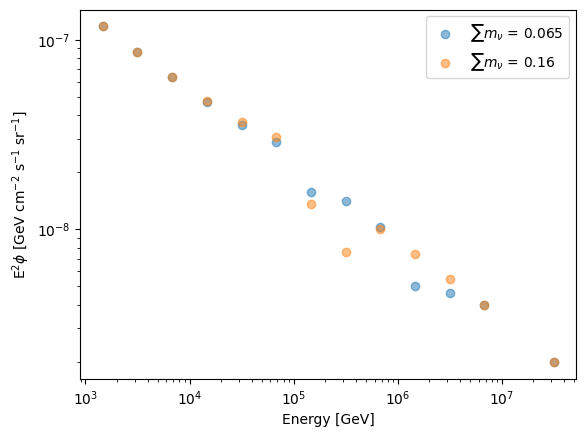

In [66]:
def integrate_nuSIprop_E2phi(theta):
    #Mphi, g, si = theta
    Mphi, g, mntot, si, norm = theta
    evolver.set_parameters(mphi=Mphi*1e6, g=g, mntot=mntot, si=si)
    evolver.evolve()
    flux = evolver.get_flux_fla()                      # shape (nE, flavors)
    E_samples = evolver.get_energies() / 1e9           # ensure same units as energy_edges_MESE (GeV)
    perflavor = (flux[0,:] + flux[1,:] + flux[2,:]) / 3.0  # or flux.T/columns depending on shape

    preds = []
    for Emin, Emax in zip(energy_edges_MESE[:-1], energy_edges_MESE[1:]):
        # select indices inside the bin (include endpoints carefully)
        mask = (E_samples >= Emin) & (E_samples <= Emax)
        Es = E_samples[mask]
        phis = perflavor[mask]

        if Es.size == 0:
            # fallback: interpolate phi on a fine grid and integrate, or use nearest neighbor
            preds.append(0.0)
            continue

        # integrate E^2 * phi(E) over the bin using trapezoid rule
        integrand = (Es**2) * phis
        integral = np.trapz(integrand, Es)   # approximates ∫ E^2 phi dE
        preds.append(integral / (Emax - Emin))   # bin-averaged E^2 phi

    return np.array(preds)


nuSIprop_1 = integrate_nuSIprop_E2phi(theta=[5, 0.001, 0.065, 2.4, 7])
nuSIprop_2 = integrate_nuSIprop_E2phi(theta=[5, 0.001, 0.12, 2.4, 7])

print('nuSIprop_1: ', nuSIprop_1)
print('nuSIprop_2: ', nuSIprop_2)

plt.scatter(energy_centers_MESE, nuSIprop_1, label=r'$\sum m_{\nu}$ = 0.065', alpha=0.5)
plt.scatter(energy_centers_MESE, nuSIprop_2, label=r'$\sum m_{\nu}$ = 0.16', alpha=0.5)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Energy [GeV]')
plt.ylabel('E$^2 \phi$ [GeV cm$^{-2}$ s$^{-1}$ sr$^{-1}$]')
plt.legend()
plt.show()


In [50]:
import h5py
file = './cluster/ultranest/mese/run6/results/points.hdf5'

with h5py.File(file, 'r') as f:
    print(f.keys())
    print(f['points'])
    print(f['points'][:][-10:])

<KeysViewHDF5 ['points']>
<HDF5 dataset "points": shape (4942, 9), type "<f8">
[[-7.11486437 -7.07163544  0.          0.52205941  0.64540193  0.21000775
   2.84926732  2.61350482  0.35451123]
 [-7.11486437 -7.06101511  0.          0.50565879  0.65300069  0.21524478
   2.77546456  2.63250173  0.36210493]
 [-7.11486437 -7.08297692  0.          0.52267076  0.64237066  0.20931672
   2.85201841  2.60592664  0.35350924]
 [-7.11486437 -7.06345886  0.          0.50762155  0.6448992   0.20613999
   2.78429697  2.61224801  0.34890299]
 [-7.11486437 -7.08431417  0.          0.5120425   0.65610147  0.21592662
   2.80419124  2.64025367  0.3630936 ]
 [-7.11486437 -7.09518654  0.          0.50629889  0.6553771   0.20500416
   2.77834499  2.63844275  0.34725604]
 [-7.11486437 -7.10011966  0.          0.51289231  0.64189716  0.21277152
   2.8080154   2.60474289  0.35851871]
 [-7.11486437 -7.10209949  0.          0.51490322  0.65446521  0.20880798
   2.81706447  2.63616301  0.35277157]
 [-7.11486437 -7.

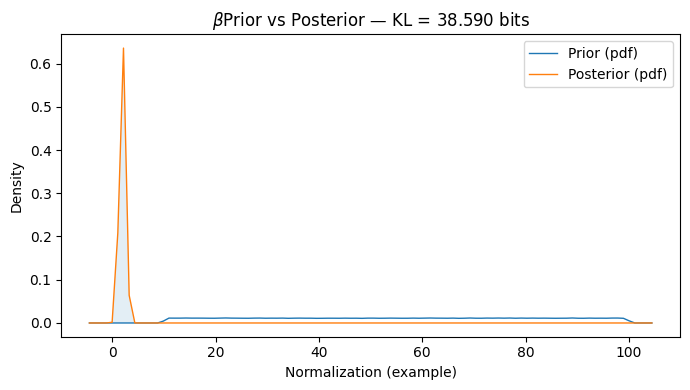

Estimated information gain (KL) = 38.5904 bits for example 1.


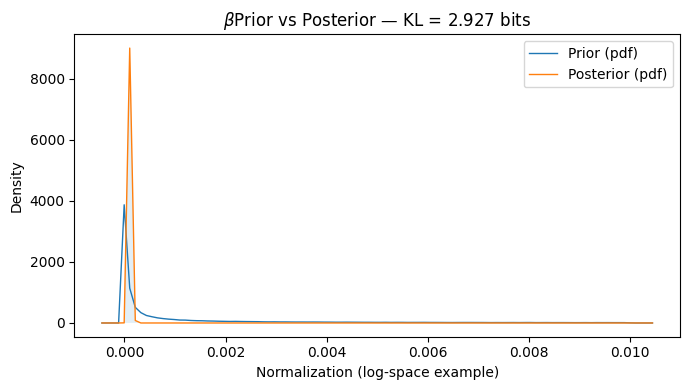

Estimated information gain (KL) = 2.9272 bits for example 2.


(38.59042234310777, 2.927167723951752)

In [16]:
# plotting prior vs posterior example and computing information gain (KL in bits)

from scipy.stats import entropy, norm
import math

def compute_kl_bits(prior_samples, posterior_samples, nbins=200, range_pad=0.05):
    """
    Estimate KL(posterior || prior) in bits using histogram discretization.
    Returns KL in bits, and the bin edges and histograms (pdf estimates).
    """
    # Build a range that covers both
    amin = min(prior_samples.min(), posterior_samples.min())
    amax = max(prior_samples.max(), posterior_samples.max())
    rng = amax - amin
    amin -= rng * range_pad
    amax += rng * range_pad

    bins = np.linspace(amin, amax, nbins+1)
    p_prior, _ = np.histogram(prior_samples, bins=bins, density=True)
    p_post, _  = np.histogram(posterior_samples, bins=bins, density=True)

    # small floor to avoid zero probabilities (necessary for stable KL)
    eps = 1e-12
    p_prior = np.maximum(p_prior, eps)
    p_post  = np.maximum(p_post, eps)

    # KL in nats: sum p_post * log(p_post / p_prior) * bin_width
    bin_widths = np.diff(bins)
    kl_nats = np.sum(p_post * np.log(p_post / p_prior) * bin_widths)
    kl_bits = kl_nats / np.log(2.0)
    return kl_bits, bins, p_prior, p_post

def plot_prior_posterior(prior_samples, posterior_samples, param_name="param", nbins=100):
    kl_bits, bins, p_prior, p_post = compute_kl_bits(prior_samples, posterior_samples, nbins=nbins)
    bin_centers = 0.5 * (bins[:-1] + bins[1:])
    plt.figure(figsize=(7,4))
    plt.plot(bin_centers, p_prior, label="Prior (pdf)", linewidth=1)
    plt.plot(bin_centers, p_post,  label="Posterior (pdf)", linewidth=1)
    plt.fill_between(bin_centers, p_post, alpha=0.12)
    plt.xlabel(param_name)
    plt.ylabel("Density")
    plt.title(r"$\beta$" +f"Prior vs Posterior — KL = {kl_bits:.3f} bits")
    plt.legend()
    plt.tight_layout()
    plt.show()
    return kl_bits

# -----------------------
# Example 1: Uniform prior on [0,10], posterior ~ Normal(2, 0.5)
np.random.seed(1)
prior_uniform = np.random.uniform(10, 100, size=200000)
posterior_synth = np.random.normal(loc=2.0, scale=0.5, size=20000)

kl_bits_example = plot_prior_posterior(prior_uniform, posterior_synth, param_name="Normalization (example)")
print(f"Estimated information gain (KL) = {kl_bits_example:.4f} bits for example 1.")

# -----------------------
# Example 2: Log-uniform prior on [1e-6, 1e-2], posterior peaked near 1e-4
prior_log = 10**(np.random.uniform(np.log10(1e-6), np.log10(1e-2), size=200000))
# posterior samples (log-normal-like)
posterior_log = np.exp(np.random.normal(np.log(1e-4), 0.2, size=20000))

kl_bits_example2 = plot_prior_posterior(prior_log, posterior_log, param_name="Normalization (log-space example)")
print(f"Estimated information gain (KL) = {kl_bits_example2:.4f} bits for example 2.")

# Return the functions in case the user wants to reuse them interactively
kl_bits_example, kl_bits_example2



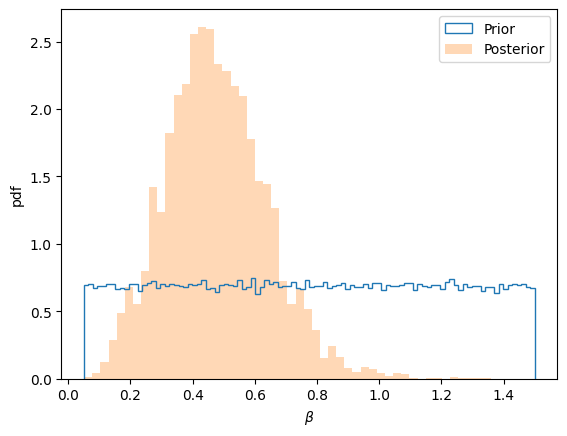

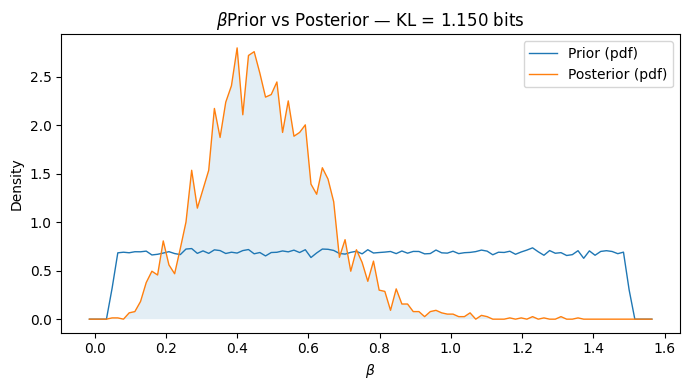

1.1500305794327912

In [17]:

# Load posterior samples

post = np.loadtxt("./cluster/ultranest/mese/run3_LP/chains/equal_weighted_post.txt", skiprows=1)
norm_post = post[:,2]  # first column = norm

# Generate synthetic prior samples (example: log-uniform in [1e-20, 1e-15])
prior_norm = np.random.uniform(0.05, 1.5, size=100000)

# Plot
plt.hist(prior_norm, bins=100, density=True, histtype='step', label="Prior")
plt.hist(norm_post, bins=50, density=True, histtype='stepfilled', alpha=0.3, label="Posterior")
plt.xlabel(r"$\beta$")
plt.ylabel("pdf")
plt.legend()
plt.show()

plot_prior_posterior(prior_norm, norm_post, param_name=r"$\beta$")
